![thumbnail](https://raw.githubusercontent.com/lko9911/Kaggle/master/thumbnail/thumbnail.png)


<div style="
    padding: 20px;
    color: white;
    margin: 0;
    font-size: 300%;
    font-weight: 800;
    text-align: center;
    display: fill;
    border-radius: 60px;
    background-color: #D8CEF6;
    box-shadow: 0 4px 8px rgba(0, 0, 0, 0.2);
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Predict Eco-Driving Scores<br>
    (ML / DL)
</div>

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Import Libraries & Read Dataset</div>

In [1]:
# For EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE

# For Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# For Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam

2026-02-02 14:20:35.703321: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770042035.979381      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770042036.060277      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770042036.762318      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770042036.762368      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770042036.762371      17 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv('/kaggle/input/eco-driving-behavior-dataset/eco_driving_score.csv')
df.head()

,rpm_variation,harsh_braking_count,idling_time,fuel_consumption,acceleration_smoothness,eco_score
0,2147,5,14.2,7.87,0.97,42.1
1,1703,3,4.2,9.37,0.50,36.1
2,2253,0,5.5,8.85,0.78,49.8
3,2866,3,21.7,5.87,0.60,27.7
4,1636,2,3.1,6.71,0.99,79.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rpm_variation            30000 non-null  int64  
 1   harsh_braking_count      30000 non-null  int64  
 2   idling_time              30000 non-null  float64
 3   fuel_consumption         30000 non-null  float64
 4   acceleration_smoothness  30000 non-null  float64
 5   eco_score                30000 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 1.4 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rpm_variation,30000.0,1807.951133,679.423972,500.00,1325.00,1801.00,2272.00,4935.00
harsh_braking_count,30000.0,2.725667,1.671038,0.00,2.00,3.00,4.00,14.00
idling_time,30000.0,11.281750,5.294333,0.00,7.60,11.20,14.90,32.50
fuel_consumption,30000.0,8.052019,1.512837,3.50,7.03,8.04,9.05,14.43
acceleration_smoothness,30000.0,0.667652,0.155482,0.03,0.56,0.67,0.78,1.00
eco_score,30000.0,47.488843,19.462413,0.00,34.60,48.40,61.30,100.00


# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Data preprocessing</div>

In [5]:
print("Missing Value (%)")
missing_values = df.isna().mean() * 100
print(missing_values)

print("\nDuplicate Rows (%):")
duplicate_count = df.duplicated().mean()
print(duplicate_count)

Missing Value (%)
rpm_variation              0.0
harsh_braking_count        0.0
idling_time                0.0
fuel_consumption           0.0
acceleration_smoothness    0.0
eco_score                  0.0
dtype: float64

Duplicate Rows (%):
0.0


In [6]:
def outlier_check(row, colname):  
    Q1 = row[colname].quantile(0.25)
    Q3 = row[colname].quantile(0.75)
    IQR = Q3 - Q1
    lower_b = Q1 - 1.5 * IQR
    upper_b = Q3 + 1.5 * IQR
    outlier = row.loc[(row[colname] < lower_b) | (row[colname] > upper_b)]
    return outlier
    
outliers = pd.DataFrame() 

for col in df.select_dtypes(include=['number']).columns: 
    outliers_in_col = outlier_check(df, col) 
    outliers = pd.concat([outliers, outliers_in_col])

outliers.reset_index(drop=True, inplace=True)

total_rows = len(df)
outlier_count = len(outliers)
outlier_ratio = (outlier_count / total_rows) * 100

if outliers.empty:
    print("No outliers")
else:
    print(f"Number of Outliers: {outlier_count}")
    print(f"Outlier Ratio: {outlier_ratio:.2f}%")

Number of Outliers: 792
Outlier Ratio: 2.64%


# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">EDA : Correlation Analysis</div>

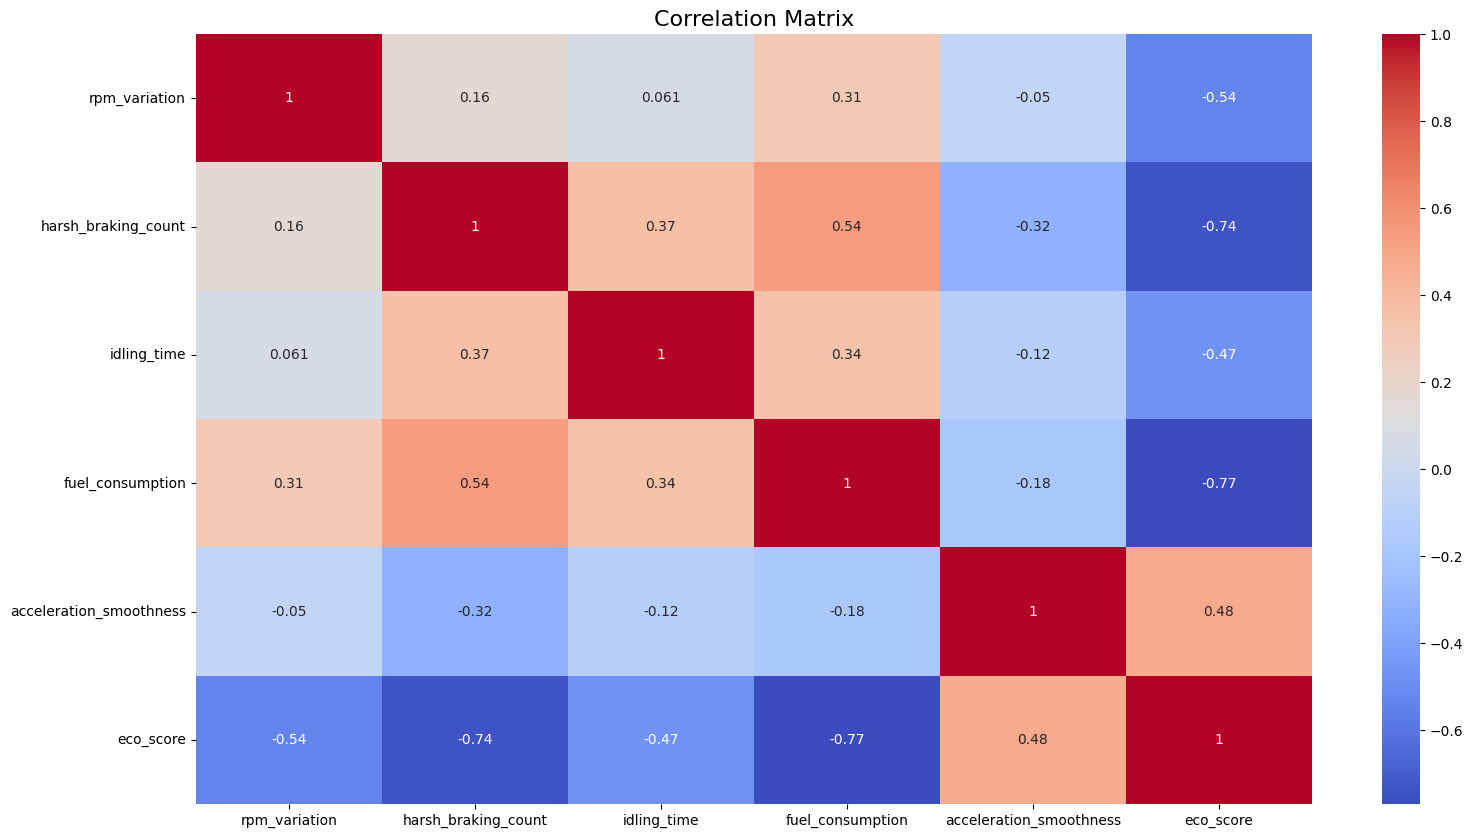

In [7]:
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

correlation_matrix = df.corr(method='pearson')

plt.figure(figsize=(18, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Comparison of Machine Learning Model Performance</div>

In [8]:
X = df.drop('eco_score', axis=1)
y = df['eco_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.01, random_state=42),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "KNN": KNeighborsRegressor(n_neighbors=3),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )
}

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return mae, mse, rmse, r2

In [9]:
results = {}

for name, model in models.items():
    mae, mse, rmse, r2 = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )
    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

results_df = pd.DataFrame(results).T  
results_df = results_df.round(4)     

results_df = results_df.reset_index().rename(columns={"index": "Model"})

results_df = results_df.round(4)     
results_df


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,3.9984,25.0131,5.0013,0.9317
1,Ridge,3.9985,25.0133,5.0013,0.9317
2,Lasso,3.9991,25.0176,5.0018,0.9317
3,SVR,4.0601,26.0548,5.1044,0.9289
4,KNN,4.7125,35.0894,5.9236,0.9043
5,Decision Tree,6.1136,59.3428,7.7034,0.8381
6,Random Forest,4.3109,29.1557,5.3996,0.9204
7,XGBoost,4.0843,26.3137,5.1297,0.9282


# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Comparison of Deep Learning Model Performance</div>

In [10]:
def plot_history(history, title="Training History"):
    plt.figure(figsize=(6, 4))
    plt.plot(history['loss'], label='Train Loss')
    
    if 'val_loss' in history:
        plt.plot(history['val_loss'], label='Validation Loss')
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [11]:
simple_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)   
])

simple_nn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',        
    metrics=['mae']    
)

simple_nn.summary()

history = simple_nn.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-02 14:21:42.859855: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1356.9075 - mae: 29.1618 - val_loss: 45.5975 - val_mae: 5.3053
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 37.8139 - mae: 4.8649 - val_loss: 27.5916 - val_mae: 4.1926
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 26.8446 - mae: 4.1317 - val_loss: 25.7496 - val_mae: 4.0597
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25.3474 - mae: 4.0224 - val_loss: 25.3526 - val_mae: 4.0277
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 24.9001 - mae: 3.9875 - val_loss: 25.1455 - val_mae: 4.0099
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.2414 - mae: 4.0248 - val_loss: 25.0315 - val_mae: 3.9958
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.1633 - mae: 4.0114 - val_loss: 24.8795 - val_mae: 3.9882
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 24.9901 - mae: 3.9764 - val_loss: 25.0525 - val_mae: 4.0014
Epoch 9/50
600/600 ━━━━━━━━━━━━━━━━━━

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MAE : 3.9752
MSE : 24.8432
RMSE: 4.9843
R2  : 0.9322


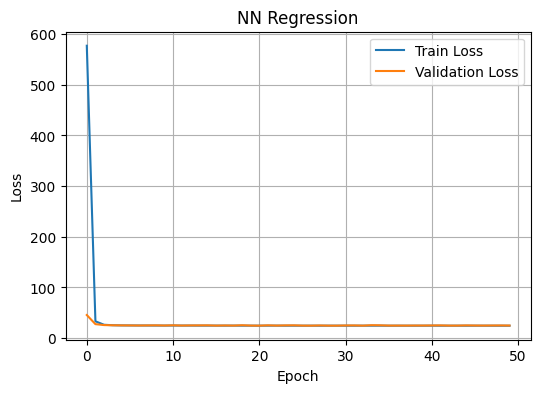

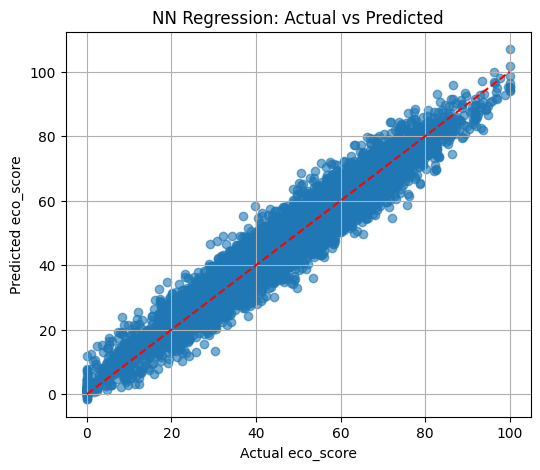

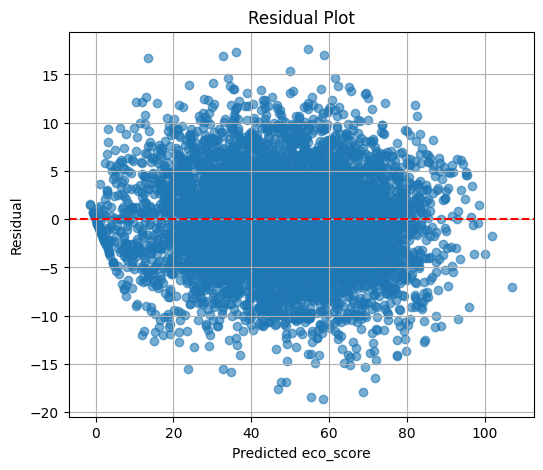

In [12]:
y_pred = simple_nn.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

plot_history(history.history, "NN Regression")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('Actual eco_score')
plt.ylabel('Predicted eco_score')
plt.title('NN Regression: Actual vs Predicted')
plt.grid(True)
plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted eco_score')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

In [13]:
DNN = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)  
])

DNN.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

DNN.summary()

history = DNN.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 703.4549 - mae: 17.6873 - val_loss: 26.8749 - val_mae: 4.1335
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 26.2239 - mae: 4.0828 - val_loss: 25.5866 - val_mae: 4.0282
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.4557 - mae: 4.0161 - val_loss: 24.8932 - val_mae: 3.9745
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.4991 - mae: 4.0190 - val_loss: 24.9491 - val_mae: 3.9722
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.4197 - mae: 3.9956 - val_loss: 24.8995 - val_mae: 3.9708
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 25.2509 - mae: 4.0119 - val_loss: 24.7846 - val_mae: 3.9548
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 24.8778 - mae: 3.9750 - val_loss: 24.9638 - val_mae: 3.9718
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.6190 - mae: 4.0362 - val_loss: 24.7260 - val_mae: 3.9569
Epoch 9/50
600/600 ━━━━━━━━━━━━━━━━━━━

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE : 3.9974
MSE : 25.1534
RMSE: 5.0153
R2  : 0.9314


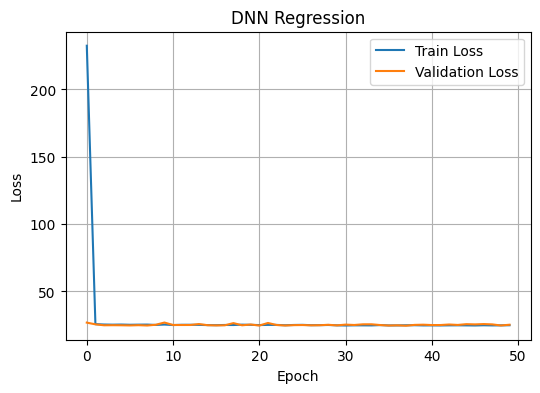

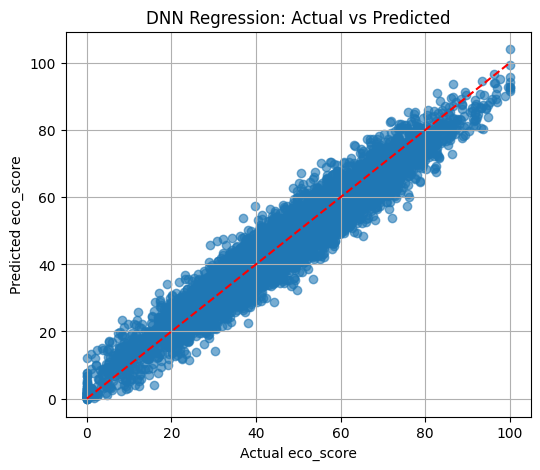

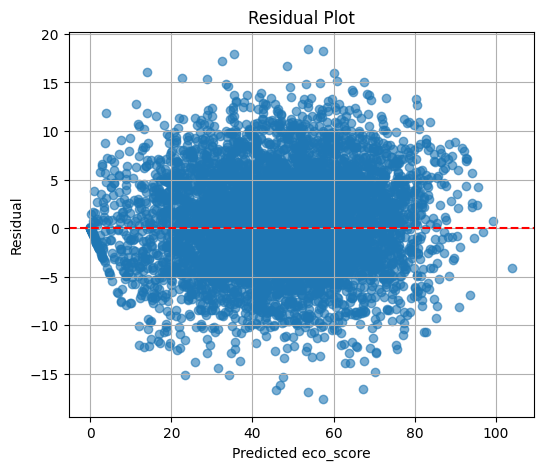

In [14]:
y_pred = DNN.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

plot_history(history.history, "DNN Regression")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('Actual eco_score')
plt.ylabel('Predicted eco_score')
plt.title('DNN Regression: Actual vs Predicted')
plt.grid(True)
plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted eco_score')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

In [15]:
MLP = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)   
])

MLP.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)


MLP.summary()

history = MLP.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1043.2786 - mae: 24.4870 - val_loss: 38.9400 - val_mae: 4.9440
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 62.5635 - mae: 6.3008 - val_loss: 27.3474 - val_mae: 4.1766
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 54.8611 - mae: 5.8326 - val_loss: 26.1619 - val_mae: 4.0830
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 52.7315 - mae: 5.6934 - val_loss: 25.7473 - val_mae: 4.0396
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 51.8144 - mae: 5.6520 - val_loss: 25.2011 - val_mae: 3.9947
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 53.0868 - mae: 5.6971 - val_loss: 25.2693 - val_mae: 4.0038
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 52.7890 - mae: 5.6620 - val_loss: 26.3229 - val_mae: 4.0819
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 51.0231 - mae: 5.5734 - val_loss: 27.0804 - val_mae: 4.1434
Epoch 9/50
600/600 ━━━━━━━━━━━━━━━━━━

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE : 4.0076
MSE : 25.1486
RMSE: 5.0148
R2  : 0.9314


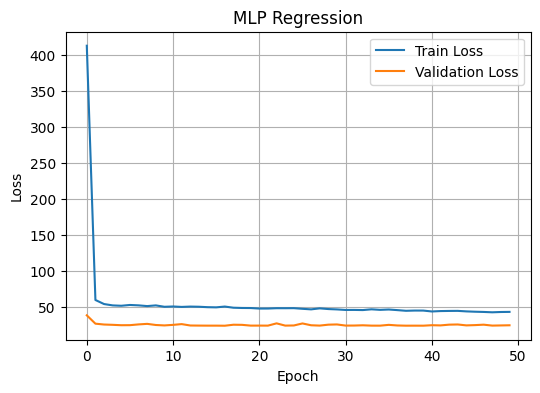

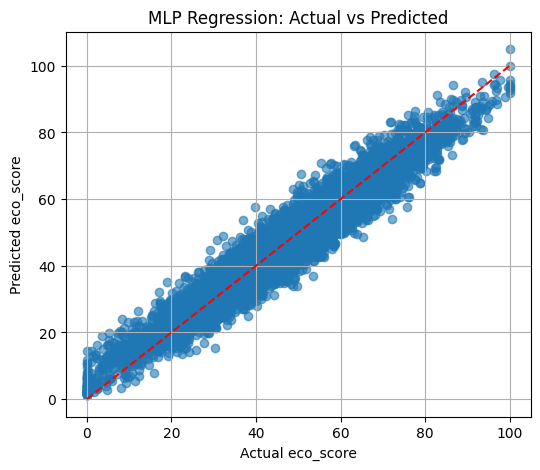

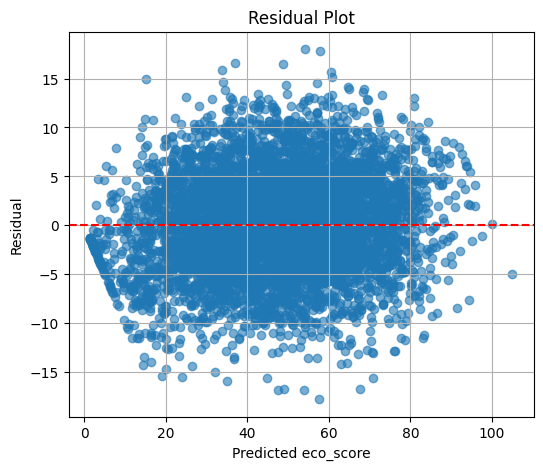

In [16]:
y_pred = MLP.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

plot_history(history.history, "MLP Regression")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('Actual eco_score')
plt.ylabel('Predicted eco_score')
plt.title('MLP Regression: Actual vs Predicted')
plt.grid(True)
plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted eco_score')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

In [17]:
def evaluate_regression_model_on_test(model, X_test, y_test):
    X_test_input = (
        X_test if len(X_test.shape) == 2
        else X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    )

    y_pred = model.predict(X_test_input, verbose=0).flatten()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return mae, mse, rmse, r2

results_deep = []

models_dict = {
    "Simple NN": simple_nn,
    "DNN": DNN,
    "MLP": MLP
}

for model_name, model in models_dict.items():
    mae, mse, rmse, r2 = evaluate_regression_model_on_test(
        model,
        X_test_scaled,
        y_test
    )

    results_deep.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

results_df2 = pd.DataFrame(results_deep)
results_df2

,Model,MAE,MSE,RMSE,R2
0,Simple NN,3.975203,24.843236,4.984299,0.932212
1,DNN,3.997428,25.153364,5.015313,0.931366
2,MLP,4.007625,25.148617,5.014840,0.931379


In [18]:
results_df = results_df.copy()
results_df2 = results_df2.copy()

standard_cols = ["Model", "MAE", "MSE", "RMSE", "R2"]
results_df = results_df[standard_cols].reset_index(drop=True)
results_df2 = results_df2[standard_cols].reset_index(drop=True)

combined_results = pd.concat([results_df, results_df2], ignore_index=True)
combined_results = combined_results.sort_values("RMSE", ascending=True)

best_model = combined_results.iloc[0]

print("Combined Results")
combined_results_df = pd.DataFrame(combined_results)
display(combined_results_df)

print("\nBest Model (Overall):")
best_model_df = pd.DataFrame(best_model)
display(best_model_df)

Combined Results


,Model,MAE,MSE,RMSE,R2
8,Simple NN,3.975203,24.843236,4.984299,0.932212
0,Linear Regression,3.998400,25.013100,5.001300,0.931700
1,Ridge,3.998500,25.013300,5.001300,0.931700
2,Lasso,3.999100,25.017600,5.001800,0.931700
10,MLP,4.007625,25.148617,5.014840,0.931379
9,DNN,3.997428,25.153364,5.015313,0.931366
3,SVR,4.060100,26.054800,5.104400,0.928900
7,XGBoost,4.084300,26.313700,5.129700,0.928200
6,Random Forest,4.310900,29.155700,5.399600,0.920400
4,KNN,4.712500,35.089400,5.923600,0.904300



Best Model (Overall):


,8
Model,Simple NN
MAE,3.975203
MSE,24.843236
RMSE,4.984299
R2,0.932212


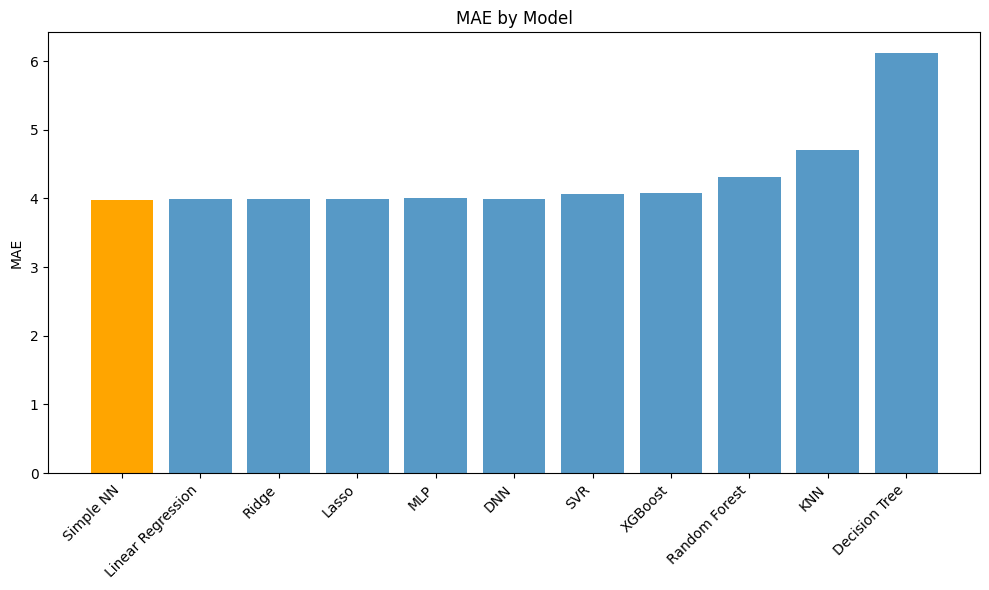

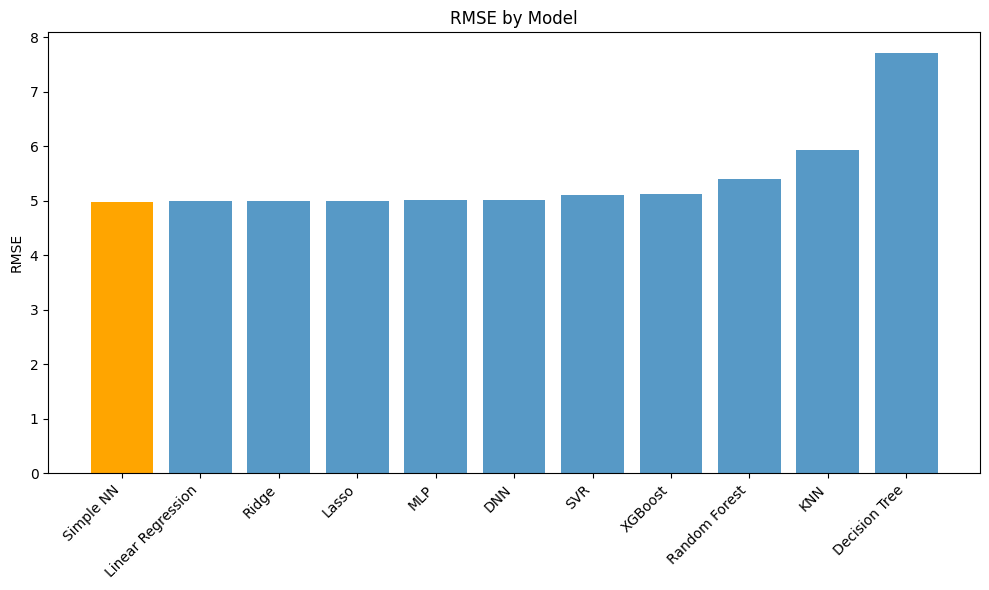

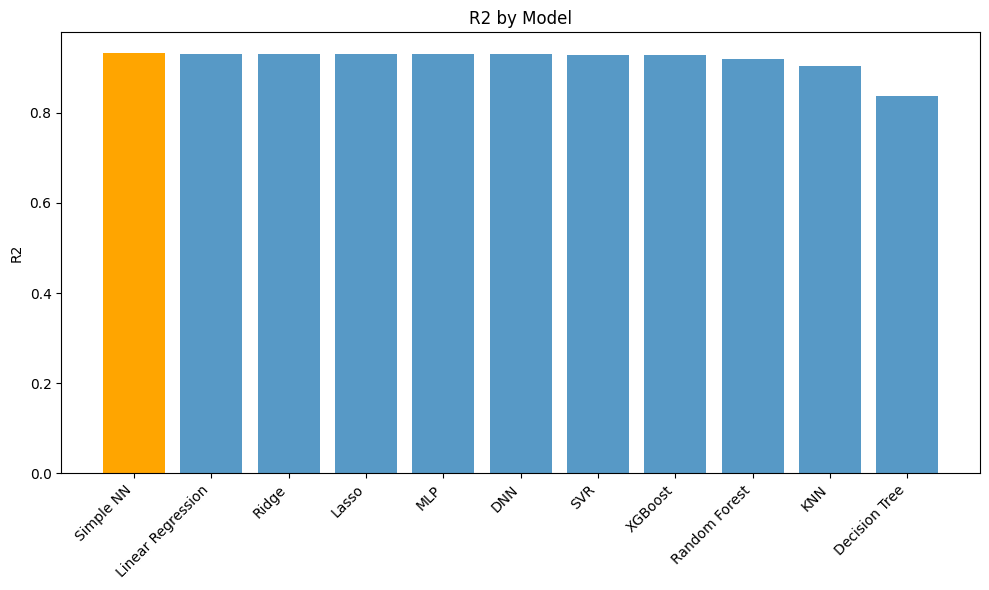


Optimal Model based on RMSE: Simple NN (RMSE = 4.9843, R2 = 0.9322)


In [19]:
metrics = ["MAE", "RMSE", "R2"]

for metric in metrics:
    plt.figure(figsize=(10, 6))
    plt.bar(combined_results["Model"], combined_results[metric], alpha=0.75)
    plt.bar(best_model["Model"], best_model[metric], alpha=1.0, color='orange')
    plt.ylabel(metric)
    plt.title(f"{metric} by Model")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

print(f"\nOptimal Model based on RMSE: {best_model['Model']} (RMSE = {best_model['RMSE']:.4f}, R2 = {best_model['R2']:.4f})")

<div style="display: inline-block; padding: 10px 15px; border-radius: 20px; background: linear-gradient(135deg, #ff7f50, #ff1493); box-shadow: 5px 5px 15px rgba(0, 0, 0, 0.3); font-size: 30px; font-family: 'Helvetica Neue', Arial, sans-serif; color: #ffffff; text-align: center; border: 2px solid #ffffff;">Thanks !</div><br><br>

<h3> Feel free to ask any questions and use the code freely! </h3><br>
<h3> If this helped you, improved performance, or if you want fine-tuning tips, please vote! It really helps a lot!! </h3><br>
<div style="text-align: center;">
    <a href="https://www.kaggle.com/lko9911" target="_blank" style="display: inline-block; background-color: #3a86ff; color: #fff; text-decoration: none; padding: 5px 10px; border-radius: 10px; margin: 15px; font-size: 25px;">Kaggle</a>
    <a href="https://github.com/lko9911" target="_blank" style="display: inline-block; background-color: #ff8c00; color: #ffffff; text-decoration: none; padding: 5px 20px; border-radius: 15px; margin: 15px; border: 2px solid #ff4500; font-size: 25px; font-family: 'Arial', sans-serif; font-weight: bold; transition: all 0.3s ease;">GitHub</a></div>